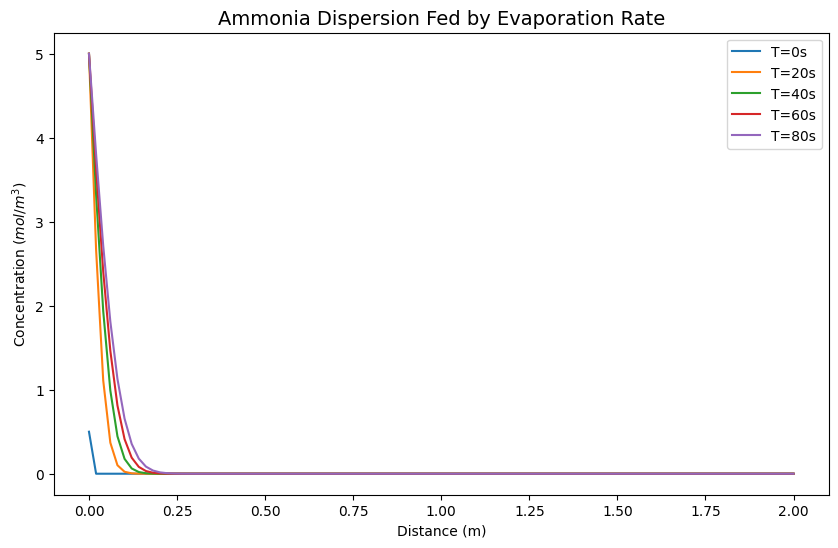

In [3]:
import numpy as np
import matplotlib.pyplot as plt

L = 2.0             # Domain length (meters)
nx = 100            # Spatial grid
dx = L / (nx - 1)
D = 0.000028        # Diffusion of NH3 in Air (m^2/s)
dt = 0.1            # Smaller time step for stability
nt = 1000           # Total time steps

# Evaporation Constants for Ammonia at 298K
P_sat = 1000000     # Saturation Pressure (approx 10 bar)
M = 0.017           # Molar mass of NH3 (kg/mol)
R = 8.314           # Gas constant
Temp = 298          # Temperature in Kelvin

C = np.zeros(nx)
liquid_pool = 5.0   # Initial amount of liquid ammonia (arbitrary units)

def get_evap_rate(pool_amount):
    """Calculates gas input based on remaining liquid"""
    if pool_amount > 0:
        # Hertz-Knudsen simplified logic
        rate = 0.05 * np.sqrt(M / (2 * np.pi * R * Temp)) * P_sat
        return min(rate, pool_amount)
    return 0

history = []
for n in range(nt):
    Cn = C.copy()
    evap_in = get_evap_rate(liquid_pool)
    liquid_pool -= evap_in * dt  # Deplete the liquid pool

    # Boundary Condition: Source term from evaporation
    C[0] = Cn[0] + evap_in * dt

    for i in range(1, nx - 1):
        # Diffusion Equation (Fick's 2nd Law)
        C[i] = Cn[i] + D * dt / dx**2 * (Cn[i+1] - 2*Cn[i] + Cn[i-1])

    if n % 200 == 0:
        history.append(C.copy())

plt.figure(figsize=(10, 6))
x_axis = np.linspace(0, L, nx)
for idx, frame in enumerate(history):
    plt.plot(x_axis, frame, label=f'T={idx*20}s')

plt.title("Ammonia Dispersion Fed by Evaporation Rate", fontsize=14)
plt.xlabel("Distance (m)")
plt.ylabel("Concentration ($mol/m^3$)")
plt.legend()
plt.show()